#  Shallow Embedding Methods

 In the realm of **semi-supervised learning on graphs**, shallow embedding methods like **Label Propagation** and **Label Spreading** serve as foundational algorithms. These methods leverage the **graph structure and limited labeled data** to infer labels for the remaining nodes.

Unlike supervised deep models (like GNNs), these algorithms do **not require training parameters**, and they propagate label information through the graph topology using simple matrix operations.



##  Unsupervised vs. Supervised Embedding Methods

The main difference between **unsupervised** and **supervised** embedding techniques lies in their objectives:

- **Unsupervised methods** aim to learn node (or graph) embeddings that preserve structural patterns, often useful for clustering or link prediction.
- **Supervised methods**, in contrast, seek to learn embeddings that are **useful for a specific prediction task**, such as **node classification**, using available label information.

Shallow methods like **Label Propagation** and **Label Spreading** fall under the umbrella of **semi-supervised learning**, where a small subset of nodes are labeled, and the goal is to infer the labels of the rest.

---

## Label Propagation Algorithm (LPA)

###  Description

The **Label Propagation Algorithm (LPA)** is a classic, non-parametric algorithm for **semi-supervised node classification**. It works by **iteratively propagating labels** from labeled nodes to their neighbors.

The key idea:  
> If two nodes are connected or likely to co-occur in a random walk, they are likely to belong to the same class.

###  Intuition

- Each labeled node **keeps its label fixed** during training.
- Labels of unlabeled nodes are updated in each iteration based on their neighbors’ current labels.
- Over time, labels diffuse throughout the graph.



### Mathematical Formulation

Let:

- $ G = (V, E) $ be the graph with $ |V| = n $ nodes.
- $ \mathbf{A} \in \mathbb{R}^{n \times n} $: Adjacency matrix
- $ \mathbf{D} $: Diagonal degree matrix, where $ D_{ii} = \sum_j A_{ij} $
- $ \mathbf{Y} \in \mathbb{R}^{n \times c} $: Label matrix (one-hot vectors for known classes):
- Each row corresponds to a node.
- If a node $ i $ is labeled with class $ k $, then $ Y_{ik} = 1 $, and all other entries in row $ i $ are zero.
- If a node is **unlabeled**, its row in $ \mathbf{Y} $ is all zeros.

The label propagation update rule is:

$$
\mathbf{F}^{(t+1)} = \mathbf{S} \cdot \mathbf{F}^{(t)}, \quad \text{where} \quad \mathbf{S} = \mathbf{D}^{-1} \mathbf{A}
$$

- $ \mathbf{F}^{(t)} $: Soft label distribution at iteration $t$
- $ \mathbf{S} $: Normalized transition matrix (row-stochastic)
- After each step, **labels of initially labeled nodes are reset** to their original values.
- $ \mathbf{F}^{(0)} = \mathbf{Y} $

That is:

- **Labeled nodes**: initialized with **one-hot vectors** corresponding to their class.
- **Unlabeled nodes**: initialized with **zero vectors**.




### Characteristics

- Fast and scalable (no learning)
- Deterministic convergence
- Sensitive to **incorrect initial labels**, because they remain unchanged and errors propagate.

---

## Label Spreading Algorithm (LSA)

###  Motivation

Label Propagation’s main weakness is its **rigid treatment of labeled nodes** — their labels remain fixed throughout the iterations. This rigidity can be harmful when:

- Labeled data is noisy or incorrect.
- The graph is sparse or contains ambiguous connections.

To address this, **Label Spreading** allows **labels to "float" and adapt**, including for initially labeled nodes.



###  Mathematical Formulation

Let:

- $ \mathbf{A} \in \mathbb{R}^{n \times n} $: Adjacency matrix
- $\mathbf{D} $: Degree matrix
- $ \mathbf{L} $: Normalized graph Laplacian

$$
\mathbf{L} = \mathbf{I} - \mathbf{D}^{-1/2} \mathbf{A} \mathbf{D}^{-1/2}
$$

Instead of using the transition matrix $ \mathbf{S} $, Label Spreading defines:

$$
\mathbf{S} = \mathbf{D}^{-1/2} \mathbf{A} \mathbf{D}^{-1/2}
$$

The update rule becomes:

$$
\mathbf{F}^{(t+1)} = \alpha \cdot \mathbf{S} \cdot \mathbf{F}^{(t)} + (1 - \alpha) \cdot \mathbf{Y}
$$

Where:

- $ \alpha \in (0,1) $: Controls the strength of propagation vs. prior label adherence
- $ \mathbf{Y}$: Original label matrix
- Unlike LPA, **initial labels are not clamped** — they evolve during training.

---

### Key Differences Between LPA and LSA

| Feature                  | Label Propagation (LPA)      | Label Spreading (LSA)        |
|--------------------------|-------------------------------|-------------------------------|
| Fixed labels             | Yes (clamped)              |  No (adaptive)              |
| Robust to noisy labels   | No                         |  Yes                        |
| Update matrix            | $ \mathbf{S} = \mathbf{D}^{-1} \mathbf{A} $ | $ \mathbf{S} = \mathbf{D}^{-1/2} \mathbf{A} \mathbf{D}^{-1/2} $ |
| Inspired by              | Random walk                   | Heat diffusion / harmonic functions |

---


## Numerical Example of LPA and LSA

We consider a simple graph with **4 nodes**:

```
Node 0 -- Node 1 -- Node 2 -- Node 3
```

- Node 0 is labeled with class 0  
- Node 3 is labeled with class 1  
- Nodes 1 and 2 are **unlabeled**

There are 2 classes in total.


Adjacency Matrix $ \mathbf{A} $

$$
\mathbf{A} =
\begin{bmatrix}
0 & 1 & 0 & 0 \\
1 & 0 & 1 & 0 \\
0 & 1 & 0 & 1 \\
0 & 0 & 1 & 0 \\
\end{bmatrix}
$$


Degree Matrix $ \mathbf{D} $

$$
\mathbf{D} = \text{diag}(1, 2, 2, 1)
$$


 Label Matrix $ \mathbf{Y} = \mathbf{F}^{(0)} $

Each node has a one-hot vector for its label:

$$
\mathbf{F}^{(0)} =
\begin{bmatrix}
1 & 0 \\
0 & 0 \\
0 & 0 \\
0 & 1 \\
\end{bmatrix}
$$

- Node 0: class 0
- Node 3: class 1
- Nodes 1 & 2: unknown


##  Label Propagation (LPA)

Transition Matrix $ \mathbf{S} = \mathbf{D}^{-1} \mathbf{A} $

$$
\mathbf{S} =
\begin{bmatrix}
0   & 1.0 & 0   & 0 \\
0.5 & 0   & 0.5 & 0 \\
0   & 0.5 & 0   & 0.5 \\
0   & 0   & 1.0 & 0 \\
\end{bmatrix}
$$


Iteration 1 (before clamping)

$$
\mathbf{F}^{(1)} = \mathbf{S} \cdot \mathbf{F}^{(0)} =
\begin{bmatrix}
0.0 & 0.0 \\
0.5 & 0.5 \\
0.0 & 0.5 \\
0.0 & 0.0 \\
\end{bmatrix}
$$

Then, **reset labeled nodes** (clamp):

$$
\mathbf{F}^{(1)} =
\begin{bmatrix}
1.0 & 0.0 \\
0.5 & 0.5 \\
0.0 & 0.5 \\
0.0 & 1.0 \\
\end{bmatrix}
$$



Iteration 2 (after clamping)

$$
\mathbf{F}^{(2)} = \mathbf{S} \cdot \mathbf{F}^{(1)} =
\begin{bmatrix}
0.5 & 0.5 \\
0.5 & 0.25 \\
0.25 & 0.75 \\
0.0 & 0.5 \\
\end{bmatrix}
$$

Reset labeled nodes again:

$$
\mathbf{F}^{(2)} =
\begin{bmatrix}
1.0 & 0.0 \\
0.5 & 0.25 \\
0.25 & 0.75 \\
0.0 & 1.0 \\
\end{bmatrix}
$$



## Label Spreading (LSA)

Normalized Transition Matrix

First compute:

$$
\mathbf{S} = \mathbf{D}^{-1/2} \cdot \mathbf{A} \cdot \mathbf{D}^{-1/2}
$$

With:

$$
\mathbf{D}^{-1/2} \approx \text{diag}(1.0,\ 0.707,\ 0.707,\ 1.0)
$$

Then:

$$
\mathbf{S} \approx
\begin{bmatrix}
0 & 0.707 & 0     & 0 \\
0.707 & 0 & 0.5   & 0 \\
0 & 0.5   & 0 & 0.707 \\
0 & 0     & 0.707 & 0 \\
\end{bmatrix}
$$



Update Rule

With $ \alpha = 0.8 $:

$$
\mathbf{F}^{(t+1)} = \alpha \cdot \mathbf{S} \cdot \mathbf{F}^{(t)} + (1 - \alpha) \cdot \mathbf{Y}
$$

Note:
- No clamping here!
- Even labeled nodes can evolve.


Summary

| Node | Initially Labeled | Final Prediction (approx.) |
|------|-------------------|-----------------------------|
| 0    | class 0        | Remains near class 0        |
| 1    | -               | Between class 0 and 1       |
| 2    | -               | Closer to class 1           |
| 3    | class 1        | Remains near class 1        |

---

- **Label Propagation**: good for clean labels, less flexible  
- **Label Spreading**: better for noisy labels, more robust  


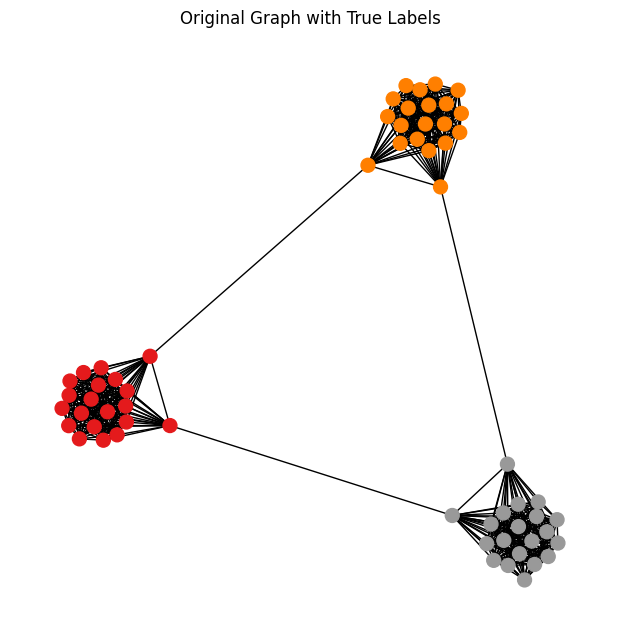

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import pairwise_kernels
from torch_geometric.utils import from_networkx, to_scipy_sparse_matrix

# Step 1: Create a synthetic graph with 3 communities
G = nx.connected_caveman_graph(3, 20)  # 3 clusters, each with 20 nodes
true_labels = []
for i in range(3):
    true_labels += [i] * 20
true_labels = np.array(true_labels)

# Visualize original graph with true labels
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(6, 6))
nx.draw(G, pos, node_color=true_labels, cmap=plt.cm.Set1, node_size=100, with_labels=False)
plt.title("Original Graph with True Labels")
plt.show()

# Convert to PyG data format
from torch_geometric.utils import from_networkx
import torch
data = from_networkx(G)
data.num_nodes = G.number_of_nodes()

# Simulate node features (for sklearn compatibility)
X = np.random.randn(data.num_nodes, 10)

# Step 2: Create semi-supervised labels
y = true_labels
y_semi = np.full_like(y, -1)
train_idx = []

# label 3 nodes per class
for c in range(3):
    idx = np.where(y == c)[0]
    np.random.seed(0)
    sel = np.random.choice(idx, 3, replace=False)
    y_semi[sel] = y[sel]
    train_idx.extend(sel)

test_idx = [i for i in range(len(y)) if i not in train_idx]




Graph-based Label Spreading Accuracy: 1.0000


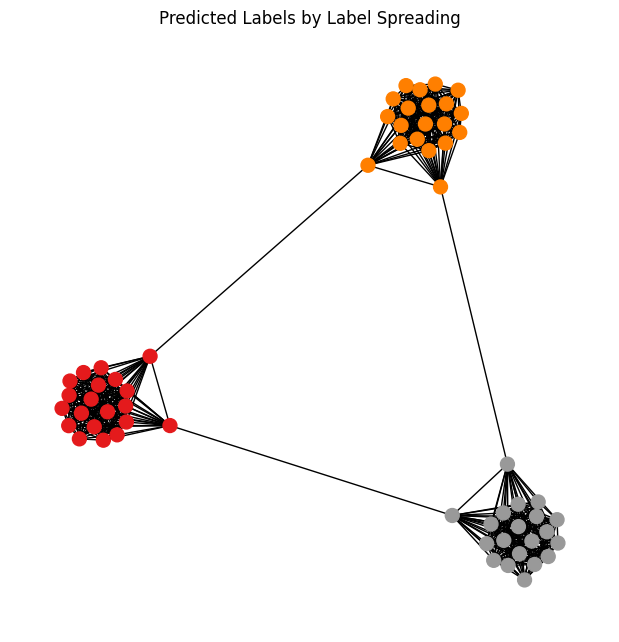

In [14]:
# Step 3: Label Spreading using graph structure as kernel

# Build adjacency
adj = to_scipy_sparse_matrix(data.edge_index, num_nodes=data.num_nodes).toarray()
W = (adj + adj.T) / 2

# Define fixed kernel
def my_affinity(X, Y=None):
    return W

# Label Spreading
model = LabelSpreading(kernel=my_affinity, alpha=0.8, max_iter=1000)
model.fit(np.zeros_like(X), y_semi)
y_pred = model.transduction_

# Accuracy
acc = accuracy_score(y[test_idx], y_pred[test_idx])
print(f"Graph-based Label Spreading Accuracy: {acc:.4f}")

# Step 4: Visualize predicted labels
plt.figure(figsize=(6, 6))
nx.draw(G, pos, node_color=y_pred, cmap=plt.cm.Set1, node_size=100, with_labels=False)
plt.title("Predicted Labels by Label Spreading")
plt.show()

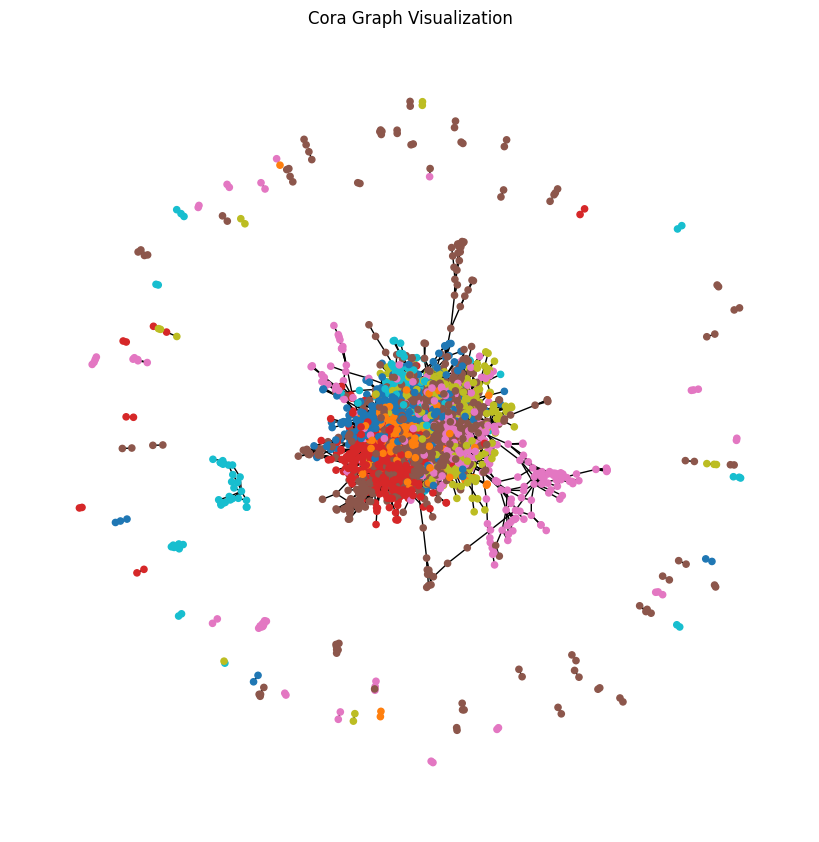

In [11]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx

# Load Cora dataset
dataset = Planetoid(root='.', name='Cora')
data = dataset[0]

# Convert to NetworkX graph
G = to_networkx(data, to_undirected=True)

# Plot
plt.figure(figsize=(8, 8))
#nx.draw(G, node_size=20, with_labels=False)
nx.draw(G, node_size=20, with_labels=False, node_color=data.y, cmap=plt.cm.tab10)
plt.title("Cora Graph Visualization")
plt.show()


In [3]:
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from torch_geometric.datasets import Planetoid
import numpy as np

# Load Cora dataset
dataset = Planetoid(root='data/Planetoid', name='Cora')
data = dataset[0]

# Convert to numpy
X = data.x.cpu().numpy()
y = data.y.cpu().numpy()
train_mask = data.train_mask.cpu().numpy()
test_mask = data.test_mask.cpu().numpy()

# Initialize semi-supervised labels
y_semi = np.full_like(y, fill_value=-1)
y_semi[train_mask] = y[train_mask]

# === Label Propagation ===
lp_model = LabelPropagation(kernel='knn', n_neighbors=10, max_iter=1000)
lp_model.fit(X, y_semi)
y_pred_lp = lp_model.transduction_

# Compute accuracy
acc_lp = np.mean(y_pred_lp[test_mask] == y[test_mask])
print(f"Label Propagation Accuracy: {acc_lp:.4f}")

# === Label Spreading ===
ls_model = LabelSpreading(kernel='knn', n_neighbors=10, alpha=0.8, max_iter=1000)
ls_model.fit(X, y_semi)
y_pred_ls = ls_model.transduction_

# Compute accuracy
acc_ls = np.mean(y_pred_ls[test_mask] == y[test_mask])
print(f"Label Spreading Accuracy: {acc_ls:.4f}")


Label Propagation Accuracy: 0.1750
Label Spreading Accuracy: 0.2330


In [7]:
from sklearn.semi_supervised import LabelSpreading
from sklearn.metrics import accuracy_score
from torch_geometric.utils import to_scipy_sparse_matrix
from sklearn.metrics.pairwise import pairwise_kernels

# Step 1: Build normalized adjacency (e.g., symmetric)
adj = to_scipy_sparse_matrix(data.edge_index, num_nodes=data.num_nodes).toarray()
W = (adj + adj.T) / 2  # symmetric

# Step 2: Define a custom kernel function (identity kernel)
def my_affinity(X, Y=None):
    return W  # just return fixed affinity regardless of input

# Step 3: Run label spreading using the custom kernel
model = LabelSpreading(kernel=my_affinity, alpha=0.8, max_iter=1000)
model.fit(np.zeros_like(X), y_semi)  # X ignored because kernel is fixed

# Step 4: Accuracy
y_pred = model.transduction_
acc = accuracy_score(y[test_mask], y_pred[test_mask])
print(f"Label Spreading (real graph) Accuracy: {acc:.4f}")


Label Spreading (real graph) Accuracy: 0.7000
